In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs

   troponina_t  presion_arterial  fibrilacion_V  diabetes      edad  objetivo  \
0     1.372514          2.200008            0.0       0.0 -0.749003         1   
1    -0.383382         -1.131843            0.0       0.0  0.741974         0   
2    -0.279255         -0.952515            0.0       0.0  0.679422         0   
3    -0.356644         -0.690994            0.0       0.0  0.313874         0   
4    -0.367074         -0.085315            0.0       0.0 -0.543954         0   

   dolor_1.0  dolor_2.0  dolor_3.0  dolor_4.0  
0          0          0          1          0  
1          1          0          0          0  
2          1          0          0          0  
3          1          0          0          0  
4          1          0          0          0  


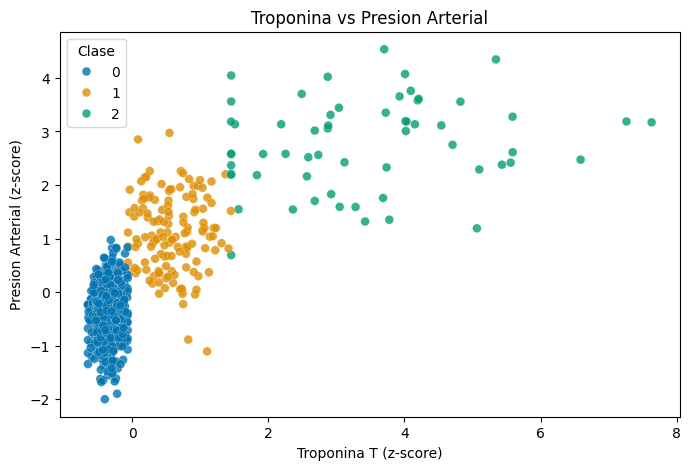

In [2]:
def generar_datos(n_samples=1000):
    np.random.seed(37)

    clases = [0, 1, 2]
    prob_clases = [0.8, 0.15, 0.05]
    y = np.random.choice(clases, size=n_samples, p=prob_clases)

    n_0 = np.sum(y == 0)
    n_1 = np.sum(y == 1)
    n_2 = np.sum(y == 2)

    #Inicializar arreglos
    troponina = np.zeros(n_samples)
    presion = np.zeros(n_samples)
    fibrilacion = np.zeros(n_samples)
    diabetes = np.zeros(n_samples)
    tipo_dolor = np.zeros(n_samples)
    edad = np.zeros(n_samples)

    troponina[y == 0] = np.clip(np.random.normal(7, 3, n_0), 0, 13.9)
    presion[y == 0] = np.random.normal(120, 10, n_0)
    fibrilacion[y == 0] = np.random.choice([0, 1], size=n_0, p=[0.99, 0.01])
    diabetes[y == 0] = np.random.choice([0, 1], size=n_0, p=[0.90, 0.10])
    tipo_dolor[y == 0] = np.random.choice([1, 2], size=n_0, p=[0.8, 0.2])
    edad[y == 0] = np.random.uniform(18, 70, n_0)
  
    troponina[y == 1] = np.clip(np.random.normal(30, 10, n_1), 14, 50)
    presion[y == 1] = np.random.normal(150, 15, n_1)
    fibrilacion[y == 1] = np.random.choice([0, 1], size=n_1, p=[0.90, 0.10])
    diabetes[y == 1] = np.random.choice([0, 1], size=n_1, p=[0.75, 0.25])
    tipo_dolor[y == 1] = np.random.choice([2, 3], size=n_1, p=[0.6, 0.4])
    edad[y == 1] = np.random.uniform(30, 85, n_1)
    
    troponina[y == 2] = np.clip(np.random.normal(100, 40, n_2), 50.1, 500)
    presion[y == 2] = np.random.normal(190, 20, n_2)
    fibrilacion[y == 2] = np.random.choice([0, 1], size=n_2, p=[0.40, 0.60])
    diabetes[y == 2] = np.random.choice([0, 1], size=n_2, p=[0.50, 0.50])
    tipo_dolor[y == 2] = np.random.choice([3, 4], size=n_2, p=[0.3, 0.7])
    edad[y == 2] = np.random.uniform(50, 95, n_2)
    
    df = pd.DataFrame({
        'troponina_t': troponina,
        'presion_arterial': presion,
        'fibrilacion_V': fibrilacion,
        'diabetes': diabetes,
        'tipo_dolor': tipo_dolor,
        'edad': edad,
        'objetivo': y
    })

    #Categorica, ocupamos OneHotEncoder 
    #Genera tantas columnas como valores tengo mi columna a transformar 
    df_final = pd.get_dummies(df, columns=['tipo_dolor'], prefix="dolor", dtype=int)

    #Estandarizacion de variables continuas
    var_continuas = ['troponina_t', 'presion_arterial', 'edad']
    # formula z = (x - media) / sigma
    
    #Estadarizamos para cada columna continua
    for col in var_continuas:
        media = df_final[col].mean()
        sigma = df_final[col].std()
        df_final[col] = (df_final[col] - media) / sigma
    
    return df_final
    
df = generar_datos()
print(df.head())

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="troponina_t",
    y="presion_arterial",
    hue="objetivo",
    palette="colorblind",
    s=40,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

ax.set_title("Troponina vs Presion Arterial")
ax.set_xlabel("Troponina T (z-score)")
ax.set_ylabel("Presion Arterial (z-score)")
ax.legend(title="Clase", frameon=True)
plt.show()



In [3]:
#Aplicammos Categorical Cross-Entropy
#Proceso Generar Logits, luego aplicar softmax, luego asignar probabilidades a cada clase

class RegresionLogistica:
    def __init__(
        self,
        semilla=37,
        tasa_aprendizaje=0.01,
        pasos_maximos=5000,
        usar_bias=True,
        tipo_regularizacion="none",   # "none", "l1", "l2", "elastic"
        fuerza_regularizacion=0.0,    # alpha
        proporcion_l1=0.5,            # solo para elastic
        balanceo_clases=None,         # None, "balanceado", o dict {clase: peso}
        tolerancia=1e-8,
        verbose=False
    ):
        # Hiperparametros
        self.semilla = semilla
        self.tasa_aprendizaje = tasa_aprendizaje
        self.pasos_maximos = pasos_maximos
        self.usar_bias = usar_bias
        self.tipo_regularizacion = tipo_regularizacion
        self.fuerza_regularizacion = fuerza_regularizacion
        self.proporcion_l1 = proporcion_l1
        self.balanceo_clases = balanceo_clases
        self.tolerancia = tolerancia
        self.verbose = verbose

        # Estado del modelo
        self.pesos = None
        self.historial_perdida = []
        self.clases = None
        self.n_clases = None
        self.indice_de_clase = None

    def _agregar_bias(self, X):
        if not self.usar_bias:
            return X
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def _softmax_estable(self, logits):
        logits = logits - np.max(logits, axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    def _a_one_hot(self, y_idx):
        if self.n_clases is None:
            raise ValueError("Error")
        Y = np.zeros((len(y_idx), int(self.n_clases)), dtype=float)
        Y[np.arange(len(y_idx)), y_idx] = 1.0
        return Y

    def _pesos_por_clase(self, y_idx):
        if self.balanceo_clases is None:
            if self.n_clases is None:
                raise ValueError("Error")
            return np.ones(self.n_clases, dtype=float)

        if self.balanceo_clases == "balanceado":
            if self.n_clases is None:
                raise ValueError("Error")
            conteos = np.bincount(y_idx, minlength=self.n_clases).astype(float)
            return len(y_idx) / (self.n_clases * np.maximum(conteos, 1.0))

        raise ValueError("balanceo_clases debe ser None, 'balanceado' o un diccionario.")

    def _perdida_regularizacion(self, W):
        if self.tipo_regularizacion == "none" or self.fuerza_regularizacion == 0:
            return 0.0

        if self.tipo_regularizacion == "l1":
            return self.fuerza_regularizacion * np.sum(np.abs(W))

        if self.tipo_regularizacion == "l2":
            return 0.5 * self.fuerza_regularizacion * np.sum(W ** 2)

        if self.tipo_regularizacion == "elastic":
            parte_l1 = self.proporcion_l1 * np.sum(np.abs(W))
            parte_l2 = 0.5 * (1.0 - self.proporcion_l1) * np.sum(W ** 2)
            return self.fuerza_regularizacion * (parte_l1 + parte_l2)

        raise ValueError("tipo_regularizacion invalido.")

    def _gradiente_regularizacion(self, W):
        if self.tipo_regularizacion == "none" or self.fuerza_regularizacion == 0:
            return np.zeros_like(W)

        if self.tipo_regularizacion == "l1":
            return self.fuerza_regularizacion * np.sign(W)

        if self.tipo_regularizacion == "l2":
            return self.fuerza_regularizacion * W

        if self.tipo_regularizacion == "elastic":
            return self.fuerza_regularizacion * (
                self.proporcion_l1 * np.sign(W) + (1.0 - self.proporcion_l1) * W
            )

        raise ValueError("tipo_regularizacion invalido.")

    def entrenar(self, X, y):
        X = X.astype(float)
        y = np.asarray(y)

        # Mapear clases reales a indices internos [0, 1, ..., K-1]
        self.clases = np.unique(y)
        self.n_clases = len(self.clases)
        self.indice_de_clase = {c: i for i, c in enumerate(self.clases)}
        y_idx = np.array([self.indice_de_clase[c] for c in y], dtype=int)

        Xb = self._agregar_bias(X)
        n_muestras, n_features = Xb.shape

        rng = np.random.default_rng(self.semilla)
        self.pesos = 0.01 * rng.normal(size=(n_features, self.n_clases))

        Y = self._a_one_hot(y_idx)

        pesos_clase = self._pesos_por_clase(y_idx)
        pesos_muestra = pesos_clase[y_idx]
        normalizador = np.sum(pesos_muestra) + 1e-12

        self.historial_perdida = []

        for paso in range(self.pasos_maximos):
            logits = Xb @ self.pesos
            probabilidades = self._softmax_estable(logits)

            perdida_ce = -np.sum(
                pesos_muestra * np.log(probabilidades[np.arange(n_muestras), y_idx] + 1e-12)
            ) / normalizador

            W = self.pesos[1:, :] if self.usar_bias else self.pesos
            perdida_total = perdida_ce + self._perdida_regularizacion(W)
            self.historial_perdida.append(perdida_total)

            # Gradiente de Softmax + Cross-Entropy ponderada
            grad_logits = (probabilidades - Y) * pesos_muestra[:, None] / normalizador
            gradiente = Xb.T @ grad_logits

            # No regularizamos bias
            grad_reg = self._gradiente_regularizacion(W)
            if self.usar_bias:
                gradiente[1:, :] += grad_reg
            else:
                gradiente += grad_reg

            self.pesos -= self.tasa_aprendizaje * gradiente

            # Criterio de convergencia
            if paso > 0:
                cambio = abs(self.historial_perdida[-2] - self.historial_perdida[-1])
                if cambio < self.tolerancia:
                    if self.verbose:
                        print(f"Convergencia en paso {paso}, perdida={perdida_total:.6f}")
                    break

        return self

    def predecir_probabilidad(self, X):
        Xb = self._agregar_bias(X.astype(float))
        if self.pesos is None:
            raise ValueError("Error")
        logits = Xb @ np.asarray(self.pesos, dtype=float)
        return self._softmax_estable(logits)

    def predecir(self, X):
        probas = self.predecir_probabilidad(X)
        idx = np.argmax(probas, axis=1)
        if self.clases is None:
            raise ValueError("Error")
        return self.clases[idx]

    def predecir_sensible_costo(self, X, matriz_costos):
        # matriz_costos[clase_real, clase_predicha]
        probas = self.predecir_probabilidad(X)
        costo_esperado = probas @ matriz_costos
        idx = np.argmin(costo_esperado, axis=1)
        if self.clases is None:
            raise ValueError("Error")
        return self.clases[idx]



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Convertir data en array para sklearn
X = np.asarray(df.drop(columns=["objetivo"]), dtype=float)
y = np.asarray(df["objetivo"], dtype=np.int64)

X_ent, X_pru, y_ent, y_pru = train_test_split(
    X, y, test_size=0.25, random_state=37, stratify=y
)

configuraciones = [
    {"nombre": "RegLog",         "tipo_regularizacion": "none",    "fuerza_regularizacion": 0.0,   "proporcion_l1": 0.0},
    {"nombre": "RegLog-L1",      "tipo_regularizacion": "l1",      "fuerza_regularizacion": 0.001, "proporcion_l1": 1.0},
    {"nombre": "RegLog-L2",      "tipo_regularizacion": "l2",      "fuerza_regularizacion": 0.001, "proporcion_l1": 0.0},
    {"nombre": "RegLog-Elastic", "tipo_regularizacion": "elastic", "fuerza_regularizacion": 0.001, "proporcion_l1": 0.5},
]

resultados = []

for cfg in configuraciones:
    modelo = RegresionLogistica(
        semilla=37,
        tasa_aprendizaje=0.05,
        pasos_maximos=6000,
        usar_bias=True,
        tipo_regularizacion=cfg["tipo_regularizacion"],
        fuerza_regularizacion=cfg["fuerza_regularizacion"],
        proporcion_l1=cfg["proporcion_l1"],
        balanceo_clases="balanceado",
        tolerancia=1e-9,
        verbose=False
    )

    modelo.entrenar(X_ent, y_ent)
    y_pred = modelo.predecir(X_pru)

    rec = recall_score(y_pru, y_pred, average=None, labels=[0, 1, 2]) #Devolmenos una matriz
    rec_arr = np.asarray(rec, dtype=float).ravel() #Convertimos a arreglo

    resultados.append({
        "modelo": cfg["nombre"],
        "accuracy": float(accuracy_score(y_pru, y_pred)),
        "f1_ponderado": float(f1_score(y_pru, y_pred, average="weighted")),
        "recall_clase_0": float(rec_arr[0]) if rec_arr.size > 0 else np.nan,
        "recall_clase_1": float(rec_arr[1]) if rec_arr.size > 1 else np.nan,
        "recall_clase_2_critica": float(rec_arr[2]) if rec_arr.size > 2 else np.nan,
        "iteraciones": int(len(modelo.historial_perdida))
    })

tabla_resultados = pd.DataFrame(resultados).sort_values("recall_clase_2_critica", ascending=False)
print(tabla_resultados.round(4))

           modelo  accuracy  f1_ponderado  recall_clase_0  recall_clase_1  \
0          RegLog     0.980        0.9806          0.9751             1.0   
1       RegLog-L1     0.976        0.9768          0.9701             1.0   
2       RegLog-L2     0.980        0.9806          0.9751             1.0   
3  RegLog-Elastic     0.976        0.9768          0.9701             1.0   

   recall_clase_2_critica  iteraciones  
0                     1.0         6000  
1                     1.0         6000  
2                     1.0         6000  
3                     1.0         6000  



=== Tabla comparativa (1-8) ===
        familia           modelo  accuracy  f1_weighted  recall_0  recall_1  \
5       sklearn     RegLog-L1-sk    0.9967       0.9966    1.0000     0.975   
4       sklearn        RegLog-sk    0.9933       0.9933    0.9959     0.975   
0  from_scratch           RegLog    0.9933       0.9933    1.0000     0.950   
2  from_scratch        RegLog-L2    0.9933       0.9933    1.0000     0.950   
6       sklearn     RegLog-L2-sk    0.9933       0.9933    1.0000     0.950   
7       sklearn  RegLog-L1-L2-sk    0.9933       0.9933    1.0000     0.950   
3  from_scratch     RegLog-L1-L2    0.9900       0.9899    1.0000     0.950   
1  from_scratch        RegLog-L1    0.9867       0.9865    1.0000     0.950   

   recall_2_critica  costo_promedio  iteraciones  
5            1.0000          0.0067          672  
4            1.0000          0.0100         2575  
0            1.0000          0.0133         6000  
2            1.0000          0.0133         6000  


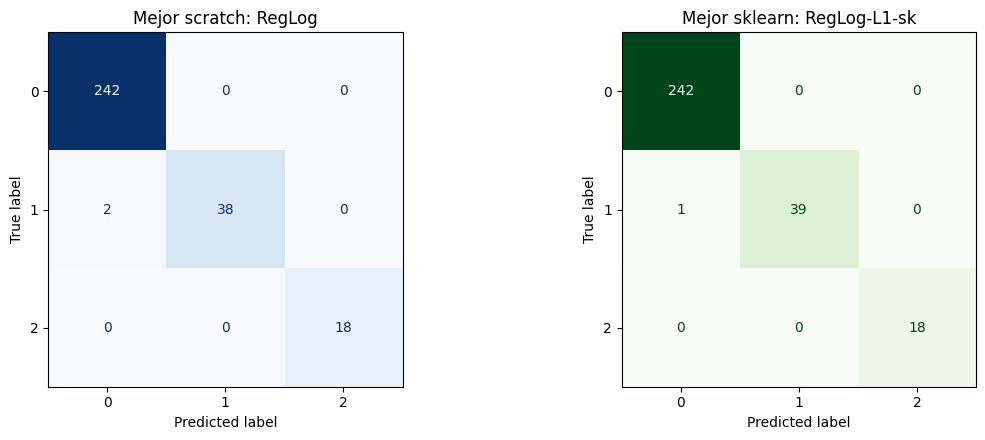


=== Sensibilidad (volumen + solapamiento) ===
    n_muestras solapamiento                       modelo  recall_critica  \
4          400         alto  RegLog-L1-L2 (scratch + cw)          1.0000   
0          400         bajo  RegLog-L1-L2 (scratch + cw)          1.0000   
2          400        medio  RegLog-L1-L2 (scratch + cw)          1.0000   
10        1200         alto  RegLog-L1-L2 (scratch + cw)          1.0000   
6         1200         bajo  RegLog-L1-L2 (scratch + cw)          1.0000   
8         1200        medio  RegLog-L1-L2 (scratch + cw)          1.0000   
16        4000         alto  RegLog-L1-L2 (scratch + cw)          0.9636   
12        4000         bajo  RegLog-L1-L2 (scratch + cw)          0.9818   
14        4000        medio  RegLog-L1-L2 (scratch + cw)          0.9818   
5          400         alto         RegLog-L1-L2-sk (cw)          1.0000   
1          400         bajo         RegLog-L1-L2-sk (cw)          1.0000   
3          400        medio         RegLo

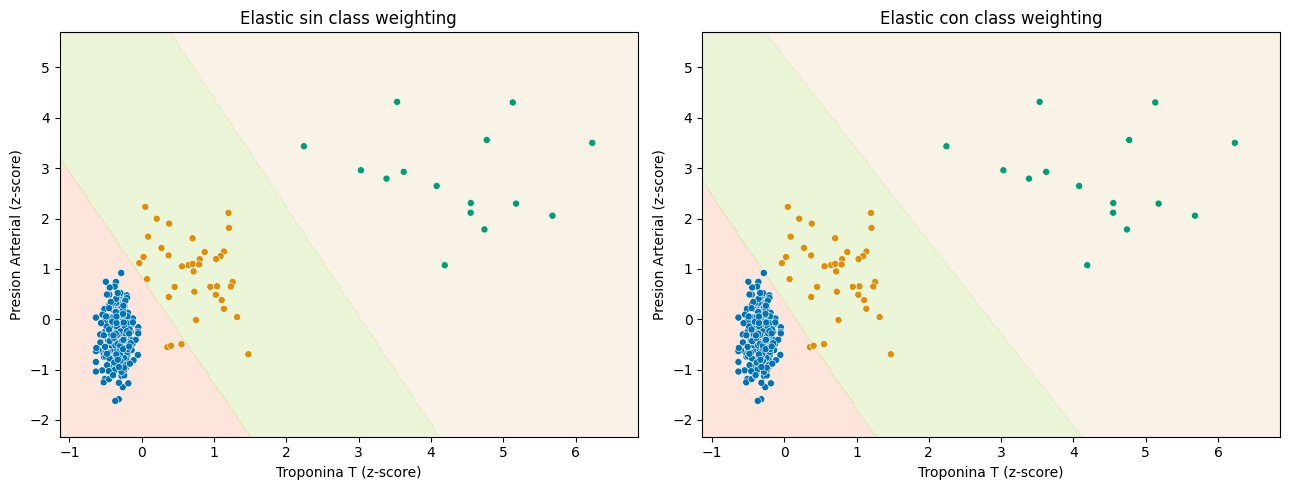


=== Importancia de atributos (top 10) ===
           atributo  importancia_scratch  importancia_sklearn
0       troponina_t               2.1454               3.0733
6         dolor_2.0               1.3847               0.5306
1  presion_arterial               1.2887               1.5971
5         dolor_1.0               1.0390               0.7901
7         dolor_3.0               1.0367               0.6610
8         dolor_4.0               0.3970               0.3869
4              edad               0.3251               0.4705
2     fibrilacion_V               0.2504               0.4608
3          diabetes               0.2252               0.3979


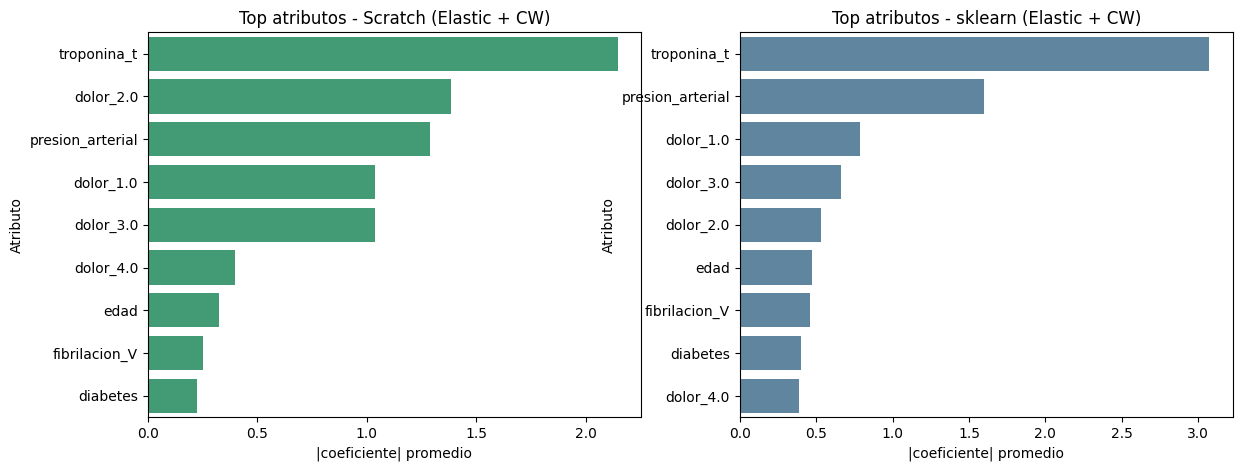

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import ParameterGrid


# 1) Dataset (tamano + solapamiento)

def generar_datos_escenario(n_samples=1000, nivel_solapamiento="medio", semilla=37):
    np.random.seed(semilla)

    if nivel_solapamiento not in {"bajo", "medio", "alto"}:
        raise ValueError("nivel_solapamiento debe ser 'bajo', 'medio' o 'alto'.")

    clases = [0, 1, 2]
    prob_clases = [0.8, 0.15, 0.05]
    y = np.random.choice(clases, size=n_samples, p=prob_clases)

    n_0 = np.sum(y == 0)
    n_1 = np.sum(y == 1)
    n_2 = np.sum(y == 2)

    troponina = np.zeros(n_samples)
    presion = np.zeros(n_samples)
    fibrilacion = np.zeros(n_samples)
    diabetes = np.zeros(n_samples)
    tipo_dolor = np.zeros(n_samples)
    edad = np.zeros(n_samples)

    if nivel_solapamiento == "bajo":
        # Clases mas separadas
        t_means, t_stds = [6, 32, 120], [2.0, 7.0, 25.0]
        p_means, p_stds = [115, 155, 200], [7.0, 12.0, 15.0]
    elif nivel_solapamiento == "medio":
        # Similar al escenario base original
        t_means, t_stds = [7, 30, 100], [3.0, 10.0, 40.0]
        p_means, p_stds = [120, 150, 190], [10.0, 15.0, 20.0]
    else:
        # Clases mas mezcladas
        t_means, t_stds = [12, 35, 70], [8.0, 16.0, 35.0]
        p_means, p_stds = [128, 148, 172], [18.0, 20.0, 22.0]

    troponina[y == 0] = np.clip(np.random.normal(t_means[0], t_stds[0], n_0), 0, 13.9)
    presion[y == 0] = np.random.normal(p_means[0], p_stds[0], n_0)
    fibrilacion[y == 0] = np.random.choice([0, 1], size=n_0, p=[0.99, 0.01])
    diabetes[y == 0] = np.random.choice([0, 1], size=n_0, p=[0.90, 0.10])
    tipo_dolor[y == 0] = np.random.choice([1, 2], size=n_0, p=[0.8, 0.2])
    edad[y == 0] = np.random.uniform(18, 70, n_0)

    troponina[y == 1] = np.clip(np.random.normal(t_means[1], t_stds[1], n_1), 14, 50)
    presion[y == 1] = np.random.normal(p_means[1], p_stds[1], n_1)
    fibrilacion[y == 1] = np.random.choice([0, 1], size=n_1, p=[0.90, 0.10])
    diabetes[y == 1] = np.random.choice([0, 1], size=n_1, p=[0.75, 0.25])
    tipo_dolor[y == 1] = np.random.choice([2, 3], size=n_1, p=[0.6, 0.4])
    edad[y == 1] = np.random.uniform(30, 85, n_1)

    troponina[y == 2] = np.clip(np.random.normal(t_means[2], t_stds[2], n_2), 50.1, 500)
    presion[y == 2] = np.random.normal(p_means[2], p_stds[2], n_2)
    fibrilacion[y == 2] = np.random.choice([0, 1], size=n_2, p=[0.40, 0.60])
    diabetes[y == 2] = np.random.choice([0, 1], size=n_2, p=[0.50, 0.50])
    tipo_dolor[y == 2] = np.random.choice([3, 4], size=n_2, p=[0.3, 0.7])
    edad[y == 2] = np.random.uniform(50, 95, n_2)

    df = pd.DataFrame({
        "troponina_t": troponina,
        "presion_arterial": presion,
        "fibrilacion_V": fibrilacion,
        "diabetes": diabetes,
        "tipo_dolor": tipo_dolor,
        "edad": edad,
        "objetivo": y,
    })

    df_final = pd.get_dummies(df, columns=["tipo_dolor"], prefix="dolor", dtype=int)

    # columnas one-hot 
    for c in ["dolor_1.0", "dolor_2.0", "dolor_3.0", "dolor_4.0"]:
        if c not in df_final.columns:
            df_final[c] = 0

    var_continuas = ["troponina_t", "presion_arterial", "edad"]
    for col in var_continuas:
        media = df_final[col].mean()
        sigma = df_final[col].std() + 1e-12
        df_final[col] = (df_final[col] - media) / sigma

    columnas_orden = [
        "troponina_t", "presion_arterial", "fibrilacion_V", "diabetes", "edad",
        "dolor_1.0", "dolor_2.0", "dolor_3.0", "dolor_4.0", "objetivo"
    ]
    return df_final[columnas_orden]


def evaluar_modelo(y_real, y_pred, matriz_costos):
    rec = recall_score(y_real, y_pred, average=None, labels=[0, 1, 2])
    cm = confusion_matrix(y_real, y_pred, labels=[0, 1, 2])

    costo_total = 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            costo_total += cm[i, j] * matriz_costos[i, j]

    return {
        "accuracy": float(accuracy_score(y_real, y_pred)),
        "f1_weighted": float(f1_score(y_real, y_pred, average="weighted")),
        "recall_0": float(rec[0]),
        "recall_1": float(rec[1]),
        "recall_2_critica": float(rec[2]),
        "costo_total": float(costo_total),
        "costo_promedio": float(costo_total / len(y_real)),
        "cm": cm,
    }


# Penalizacion fuerte al falso negativo critico
matriz_costos = np.array([
    [0, 1, 2],
    [2, 0, 5],
    [50, 8, 0],
], dtype=float)

# 2) Comparacion completa: from scratch (1-4) vs sklearn (5-8)

df_base = generar_datos_escenario(n_samples=1200, nivel_solapamiento="medio", semilla=37)
X = np.asarray(df_base.drop(columns=["objetivo"]), dtype=float)
y = np.asarray(df_base["objetivo"], dtype=np.int64)

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=0.25, random_state=37, stratify=y)

resultados = []

# 1-4 from scratch
configs_scratch = [
    {"nombre": "RegLog", "tipo_regularizacion": "none", "fuerza_regularizacion": 0.0, "proporcion_l1": 0.0},
    {"nombre": "RegLog-L1", "tipo_regularizacion": "l1", "fuerza_regularizacion": 0.001, "proporcion_l1": 1.0},
    {"nombre": "RegLog-L2", "tipo_regularizacion": "l2", "fuerza_regularizacion": 0.001, "proporcion_l1": 0.0},
    {"nombre": "RegLog-L1-L2", "tipo_regularizacion": "elastic", "fuerza_regularizacion": 0.001, "proporcion_l1": 0.5},
]

for cfg in configs_scratch:
    modelo = RegresionLogistica(
        semilla=37,
        tasa_aprendizaje=0.05,
        pasos_maximos=6000,
        usar_bias=True,
        tipo_regularizacion=cfg["tipo_regularizacion"],
        fuerza_regularizacion=cfg["fuerza_regularizacion"],
        proporcion_l1=cfg["proporcion_l1"],
        balanceo_clases=None,
        tolerancia=1e-9,
        verbose=False,
    )
    modelo.entrenar(X_ent, y_ent)
    y_pred = modelo.predecir(X_pru)
    met = evaluar_modelo(y_pru, y_pred, matriz_costos)

    resultados.append({
        "familia": "from_scratch",
        "modelo": cfg["nombre"],
        "accuracy": met["accuracy"],
        "f1_weighted": met["f1_weighted"],
        "recall_0": met["recall_0"],
        "recall_1": met["recall_1"],
        "recall_2_critica": met["recall_2_critica"],
        "costo_promedio": met["costo_promedio"],
        "iteraciones": int(len(modelo.historial_perdida)),
    })

# 5-8 sklearn
configs_sk = [
    {"nombre": "RegLog-sk", "penalty": None, "C": 1.0, "l1_ratio": None},
    {"nombre": "RegLog-L1-sk", "penalty": "l1", "C": 1.0, "l1_ratio": None},
    {"nombre": "RegLog-L2-sk", "penalty": "l2", "C": 1.0, "l1_ratio": None},
    {"nombre": "RegLog-L1-L2-sk", "penalty": "elasticnet", "C": 1.0, "l1_ratio": 0.5},
]

for cfg in configs_sk:
    modelo_sk = LogisticRegression(
        penalty=cfg["penalty"],
        C=cfg["C"],
        l1_ratio=cfg["l1_ratio"],
        solver="saga",
        max_iter=5000,
        random_state=37,
    )
    modelo_sk.fit(X_ent, y_ent)
    y_pred = modelo_sk.predict(X_pru)
    met = evaluar_modelo(y_pru, y_pred, matriz_costos)

    resultados.append({
        "familia": "sklearn",
        "modelo": cfg["nombre"],
        "accuracy": met["accuracy"],
        "f1_weighted": met["f1_weighted"],
        "recall_0": met["recall_0"],
        "recall_1": met["recall_1"],
        "recall_2_critica": met["recall_2_critica"],
        "costo_promedio": met["costo_promedio"],
        "iteraciones": int(np.max(modelo_sk.n_iter_)),
    })

tabla_comparativa = pd.DataFrame(resultados).sort_values(
    ["recall_2_critica", "f1_weighted"], ascending=False
)
print("\n=== Tabla comparativa (1-8) ===")
print(tabla_comparativa.round(4))


# 3) Matriz de confusion para mejores modelos 

best_scratch = tabla_comparativa[tabla_comparativa["familia"] == "from_scratch"].iloc[0]["modelo"]
best_sk = tabla_comparativa[tabla_comparativa["familia"] == "sklearn"].iloc[0]["modelo"]

cfg_best_s = [c for c in configs_scratch if c["nombre"] == best_scratch][0]
modelo_best_s = RegresionLogistica(
    semilla=37,
    tasa_aprendizaje=0.05,
    pasos_maximos=6000,
    usar_bias=True,
    tipo_regularizacion=cfg_best_s["tipo_regularizacion"],
    fuerza_regularizacion=cfg_best_s["fuerza_regularizacion"],
    proporcion_l1=cfg_best_s["proporcion_l1"],
    balanceo_clases=None,
    tolerancia=1e-9,
    verbose=False,
)
modelo_best_s.entrenar(X_ent, y_ent)
y_pred_s = modelo_best_s.predecir(X_pru)
cm_s = confusion_matrix(y_pru, y_pred_s, labels=[0, 1, 2])

cfg_best_sk = [c for c in configs_sk if c["nombre"] == best_sk][0]
modelo_best_sk = LogisticRegression(
    penalty=cfg_best_sk["penalty"],
    C=cfg_best_sk["C"],
    l1_ratio=cfg_best_sk["l1_ratio"],
    solver="saga",
    max_iter=5000,
    random_state=37,
)
modelo_best_sk.fit(X_ent, y_ent)
y_pred_sk = modelo_best_sk.predict(X_pru)
cm_sk = confusion_matrix(y_pru, y_pred_sk, labels=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(cm_s, display_labels=[0, 1, 2]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Mejor scratch: {best_scratch}")
ConfusionMatrixDisplay(cm_sk, display_labels=[0, 1, 2]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Mejor sklearn: {best_sk}")
plt.tight_layout()
plt.show()

# 4) Sensibilidad: volumen y solapamiento

escenarios_n = [400, 1200, 4000]
escenarios_overlap = ["bajo", "medio", "alto"]
res_sens = []

for n in escenarios_n:
    for overlap in escenarios_overlap:
        df_sc = generar_datos_escenario(n_samples=n, nivel_solapamiento=overlap, semilla=37)
        X_sc = np.asarray(df_sc.drop(columns=["objetivo"]), dtype=float)
        y_sc = np.asarray(df_sc["objetivo"], dtype=np.int64)
        Xe, Xp, ye, yp = train_test_split(X_sc, y_sc, test_size=0.25, random_state=37, stratify=y_sc)

        mod_s = RegresionLogistica(
            semilla=37,
            tasa_aprendizaje=0.05,
            pasos_maximos=6000,
            usar_bias=True,
            tipo_regularizacion="elastic",
            fuerza_regularizacion=0.001,
            proporcion_l1=0.5,
            balanceo_clases="balanceado",
            tolerancia=1e-9,
            verbose=False,
        )
        mod_s.entrenar(Xe, ye)
        yp_s = mod_s.predecir(Xp)
        met_s = evaluar_modelo(yp, yp_s, matriz_costos)

        mod_sk = LogisticRegression(
            penalty="elasticnet",
            C=1.0,
            l1_ratio=0.5,
            solver="saga",
            class_weight="balanced",
            max_iter=5000,
            random_state=37,
        )
        mod_sk.fit(Xe, ye)
        yp_sk = mod_sk.predict(Xp)
        met_sk = evaluar_modelo(yp, yp_sk, matriz_costos)

        res_sens.append({
            "n_muestras": n,
            "solapamiento": overlap,
            "modelo": "RegLog-L1-L2 (scratch + cw)",
            "recall_critica": met_s["recall_2_critica"],
            "f1_weighted": met_s["f1_weighted"],
            "costo_promedio": met_s["costo_promedio"],
        })

        res_sens.append({
            "n_muestras": n,
            "solapamiento": overlap,
            "modelo": "RegLog-L1-L2-sk (cw)",
            "recall_critica": met_sk["recall_2_critica"],
            "f1_weighted": met_sk["f1_weighted"],
            "costo_promedio": met_sk["costo_promedio"],
        })

tabla_sens = pd.DataFrame(res_sens)
print("\n=== Sensibilidad (volumen + solapamiento) ===")
print(tabla_sens.sort_values(["modelo", "n_muestras", "solapamiento"]).round(4))


# 5) Grid search simple (scratch y sklearn) en Elastic Net

df_gs = generar_datos_escenario(n_samples=1200, nivel_solapamiento="medio", semilla=91)
X_gs = np.asarray(df_gs.drop(columns=["objetivo"]), dtype=float)
y_gs = np.asarray(df_gs["objetivo"], dtype=np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_gs, y_gs, test_size=0.4, random_state=37, stratify=y_gs
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=37, stratify=y_temp
)

# Grid scratch
param_grid_s = {
    "tasa_aprendizaje": [0.01, 0.03, 0.05],
    "fuerza_regularizacion": [0.0005, 0.001, 0.005],
    "proporcion_l1": [0.3, 0.5, 0.7],
}

mejor_score_s = -np.inf
mejor_cfg_s = None

for p in ParameterGrid(param_grid_s):
    m = RegresionLogistica(
        semilla=37,
        tasa_aprendizaje=p["tasa_aprendizaje"],
        pasos_maximos=6000,
        usar_bias=True,
        tipo_regularizacion="elastic",
        fuerza_regularizacion=p["fuerza_regularizacion"],
        proporcion_l1=p["proporcion_l1"],
        balanceo_clases="balanceado",
        tolerancia=1e-9,
        verbose=False,
    )
    m.entrenar(X_train, y_train)
    yp = m.predecir(X_val)
    met = evaluar_modelo(y_val, yp, matriz_costos)

    # Prioriza recall critico y luego costo
    score = met["recall_2_critica"] - 0.02 * met["costo_promedio"]
    if score > mejor_score_s:
        mejor_score_s = score
        mejor_cfg_s = {**p, "score": score, "recall_critica": met["recall_2_critica"], "costo": met["costo_promedio"]}

print("\nMejor config scratch (grid):", mejor_cfg_s)

# Grid sklearn
param_grid_sk = {
    "C": [0.5, 1.0, 2.0],
    "l1_ratio": [0.3, 0.5, 0.7],
    "class_weight": [None, "balanced"],
}

mejor_score_sk = -np.inf
mejor_cfg_sk = None

for p in ParameterGrid(param_grid_sk):
    m = LogisticRegression(
        penalty="elasticnet",
        C=p["C"],
        l1_ratio=p["l1_ratio"],
        solver="saga",
        class_weight=p["class_weight"],
        max_iter=5000,
        random_state=37,
    )
    m.fit(X_train, y_train)
    yp = m.predict(X_val)
    met = evaluar_modelo(y_val, yp, matriz_costos)
    score = met["recall_2_critica"] - 0.02 * met["costo_promedio"]

    if score > mejor_score_sk:
        mejor_score_sk = score
        mejor_cfg_sk = {**p, "score": score, "recall_critica": met["recall_2_critica"], "costo": met["costo_promedio"]}

print("Mejor config sklearn (grid):", mejor_cfg_sk)


# 6) Class weighting + costos asimetricos (

df_c = generar_datos_escenario(n_samples=1400, nivel_solapamiento="medio", semilla=123)
X_c = np.asarray(df_c.drop(columns=["objetivo"]), dtype=float)
y_c = np.asarray(df_c["objetivo"], dtype=np.int64)
Xe, Xp, ye, yp = train_test_split(X_c, y_c, test_size=0.25, random_state=37, stratify=y_c)

# A) Elastic sin class weighting
m_a = RegresionLogistica(
    semilla=37, tasa_aprendizaje=0.05, pasos_maximos=6000,
    usar_bias=True, tipo_regularizacion="elastic", fuerza_regularizacion=0.001,
    proporcion_l1=0.5, balanceo_clases=None, tolerancia=1e-9, verbose=False
)
m_a.entrenar(Xe, ye)
yp_a = m_a.predecir(Xp)
met_a = evaluar_modelo(yp, yp_a, matriz_costos)

# B) Elastic con class weighting
m_b = RegresionLogistica(
    semilla=37, tasa_aprendizaje=0.05, pasos_maximos=6000,
    usar_bias=True, tipo_regularizacion="elastic", fuerza_regularizacion=0.001,
    proporcion_l1=0.5, balanceo_clases="balanceado", tolerancia=1e-9, verbose=False
)
m_b.entrenar(Xe, ye)
yp_b = m_b.predecir(Xp)
met_b = evaluar_modelo(yp, yp_b, matriz_costos)

# C) Elastic con class weighting + decision sensible a costo
yp_costo = m_b.predecir_sensible_costo(Xp, matriz_costos)
met_c = evaluar_modelo(yp, yp_costo, matriz_costos)

tabla_costos = pd.DataFrame([
    {
        "escenario": "Elastic sin weighting",
        "recall_critica": met_a["recall_2_critica"],
        "f1_weighted": met_a["f1_weighted"],
        "accuracy": met_a["accuracy"],
        "costo_promedio": met_a["costo_promedio"],
    },
    {
        "escenario": "Elastic + class weighting",
        "recall_critica": met_b["recall_2_critica"],
        "f1_weighted": met_b["f1_weighted"],
        "accuracy": met_b["accuracy"],
        "costo_promedio": met_b["costo_promedio"],
    },
    {
        "escenario": "Elastic + weighting + decision por costo",
        "recall_critica": met_c["recall_2_critica"],
        "f1_weighted": met_c["f1_weighted"],
        "accuracy": met_c["accuracy"],
        "costo_promedio": met_c["costo_promedio"],
    },
])

print("\n=== Impacto de class weighting y costo asimetrico ===")
print(tabla_costos.round(4))


# 7) Frontera de decision para ver efecto del CW

df_2d = generar_datos_escenario(n_samples=1200, nivel_solapamiento="medio", semilla=77)
X2 = np.asarray(df_2d[["troponina_t", "presion_arterial"]], dtype=float)
y2 = np.asarray(df_2d["objetivo"], dtype=np.int64)
X2e, X2p, y2e, y2p = train_test_split(X2, y2, test_size=0.25, random_state=37, stratify=y2)

m2_sin = RegresionLogistica(
    semilla=37, tasa_aprendizaje=0.05, pasos_maximos=6000,
    usar_bias=True, tipo_regularizacion="elastic", fuerza_regularizacion=0.001,
    proporcion_l1=0.5, balanceo_clases=None, tolerancia=1e-9, verbose=False
)
m2_bal = RegresionLogistica(
    semilla=37, tasa_aprendizaje=0.05, pasos_maximos=6000,
    usar_bias=True, tipo_regularizacion="elastic", fuerza_regularizacion=0.001,
    proporcion_l1=0.5, balanceo_clases="balanceado", tolerancia=1e-9, verbose=False
)

m2_sin.entrenar(X2e, y2e)
m2_bal.entrenar(X2e, y2e)

x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
Xg = np.c_[xx.ravel(), yy.ravel()]

Z_sin = m2_sin.predecir(Xg).reshape(xx.shape)
Z_bal = m2_bal.predecir(Xg).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, Z, titulo in [
    (axes[0], Z_sin, "Elastic sin class weighting"),
    (axes[1], Z_bal, "Elastic con class weighting"),
]:
    ax.contourf(xx, yy, Z, alpha=0.22, levels=[-0.5, 0.5, 1.5, 2.5], cmap="Set2")
    sns.scatterplot(x=X2p[:, 0], y=X2p[:, 1], hue=y2p, palette="colorblind", s=26, ax=ax, legend=False)
    ax.set_title(titulo)
    ax.set_xlabel("Troponina T (z-score)")
    ax.set_ylabel("Presion Arterial (z-score)")

plt.tight_layout()
plt.show()


# 8) Importancia de atributos, tenemos en cuenta la magnitud

nombres_features = df_base.drop(columns=["objetivo"]).columns.tolist()

# Reentrenar mejor scratch 
m_imp = RegresionLogistica(
    semilla=37,
    tasa_aprendizaje=0.05,
    pasos_maximos=6000,
    usar_bias=True,
    tipo_regularizacion="elastic",
    fuerza_regularizacion=0.001,
    proporcion_l1=0.5,
    balanceo_clases="balanceado",
    tolerancia=1e-9,
    verbose=False,
)
m_imp.entrenar(X_ent, y_ent)

W_s = m_imp.pesos[1:, :] if m_imp.usar_bias else m_imp.pesos
imp_s = np.mean(np.abs(W_s), axis=1)

m_imp_sk = LogisticRegression(
    penalty="elasticnet",
    C=1.0,
    l1_ratio=0.5,
    solver="saga",
    class_weight="balanced",
    max_iter=5000,
    random_state=37,
)
m_imp_sk.fit(X_ent, y_ent)
imp_sk = np.mean(np.abs(m_imp_sk.coef_), axis=0)

df_imp = pd.DataFrame({
    "atributo": nombres_features,
    "importancia_scratch": imp_s,
    "importancia_sklearn": imp_sk,
}).sort_values("importancia_scratch", ascending=False)

print("\n=== Importancia de atributos (top 10) ===")
print(df_imp.head(10).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_imp.head(10), x="importancia_scratch", y="atributo", color="#3a7", ax=axes[0])
axes[0].set_title("Top atributos - Scratch (Elastic + CW)")
axes[0].set_xlabel("|coeficiente| promedio")
axes[0].set_ylabel("Atributo")

sns.barplot(data=df_imp.sort_values("importancia_sklearn", ascending=False).head(10),
            x="importancia_sklearn", y="atributo", color="#58a", ax=axes[1])
axes[1].set_title("Top atributos - sklearn (Elastic + CW)")
axes[1].set_xlabel("|coeficiente| promedio")
axes[1].set_ylabel("Atributo")

plt.show()
